Dataset loaded!
Shape: (7789, 11)
  Show_Id Category  Title           Director  \
0      s1  TV Show     3%                NaN   
1      s2    Movie  07:19  Jorge Michel Grau   
2      s3    Movie  23:59       Gilbert Chan   
3      s4    Movie      9        Shane Acker   
4      s5    Movie     21     Robert Luketic   

                                                Cast        Country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...         Brazil   
1  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico   
2  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore   
3  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States   
4  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States   

        Release_Date Rating   Duration  \
0    August 14, 2020  TV-MA  4 Seasons   
1  December 23, 2016  TV-MA     93 min   
2  December 20, 2018      R     78 min   
3  November 16, 2017  PG-13     80 min   
4    January 1, 2020  PG-13    123 min  

/tmp/ipython-input-131801318.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna('Unknown', inplace=True)  # Handle missing data


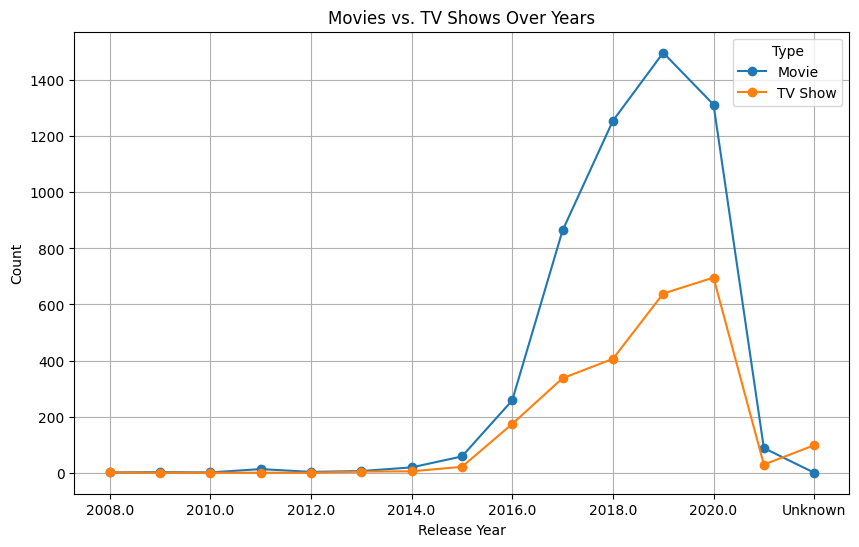

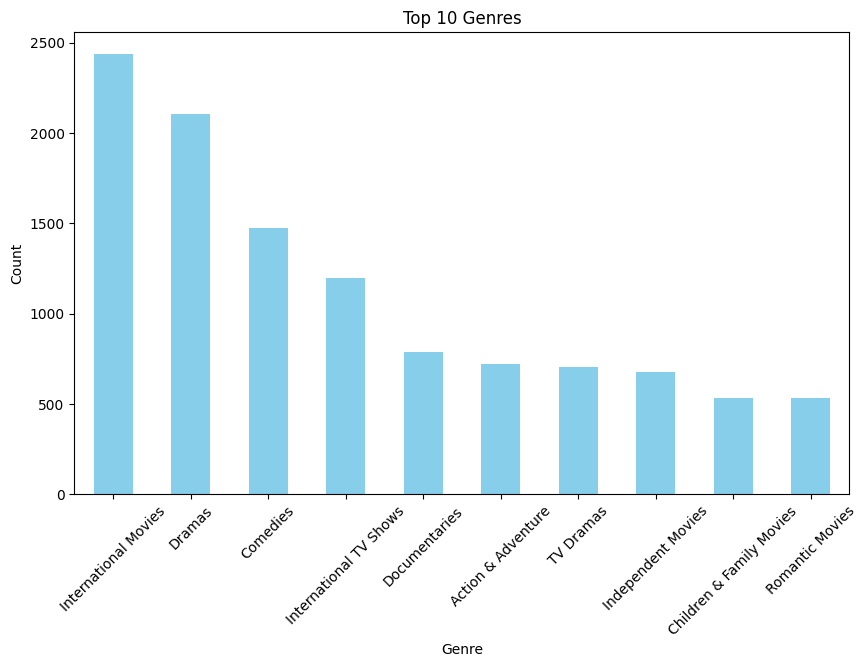

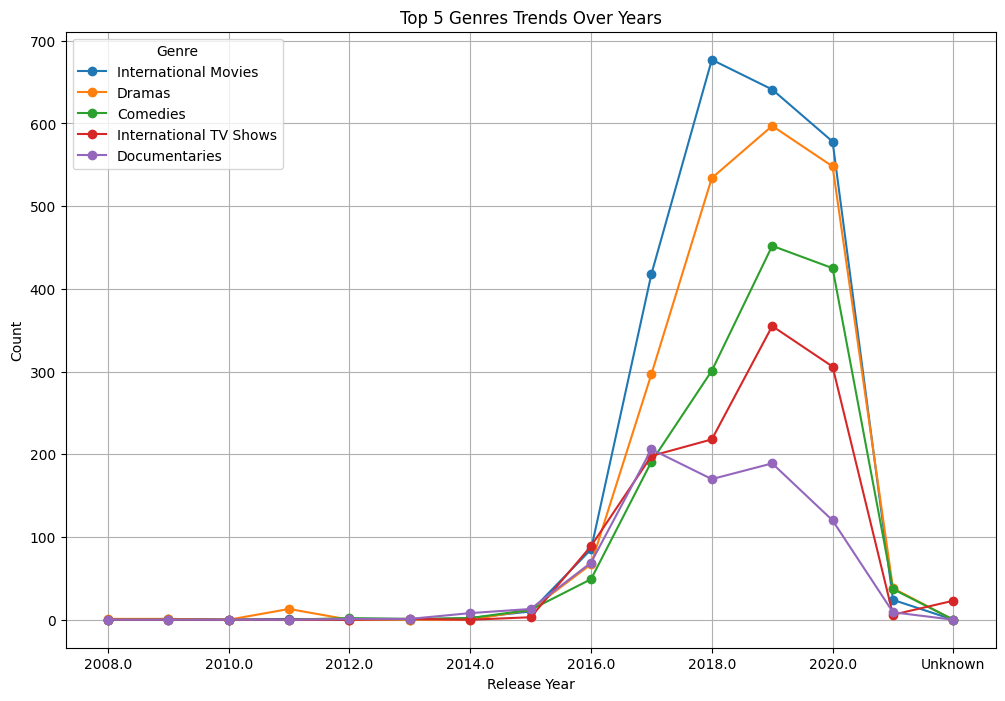

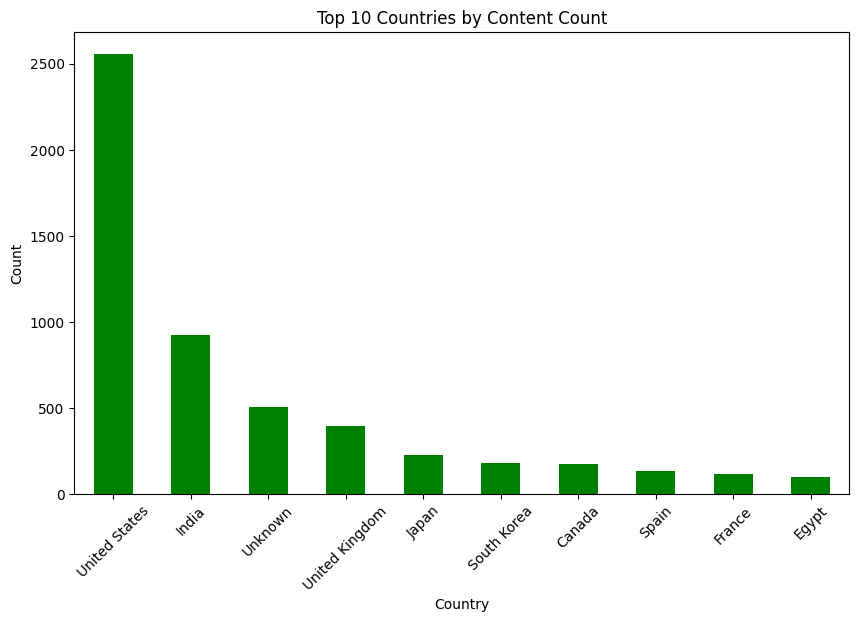

ValueError: cannot reindex on an axis with duplicate labels

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset (update filename if needed)
file_path = 'Netflix.csv'  # Change to your uploaded file's name
df = pd.read_csv(file_path)

# Quick check
print("Dataset loaded!")
print(f"Shape: {df.shape}")
print(df.head())

# Data prep: Extract year from Release_Date, rename for ease
df['release_year'] = pd.to_datetime(df['Release_Date'], errors='coerce').dt.year
df['type'] = df['Category']  # Movie/TV Show
df['genres'] = df['Type'].str.split(', ')  # Split genres
df.fillna('Unknown', inplace=True)  # Handle missing data

# Visual 1: Movies vs. TV Shows over years (Line chart)
movie_tv_trend = df.groupby(['release_year', 'type']).size().unstack().fillna(0)
movie_tv_trend.plot(kind='line', figsize=(10, 6), marker='o')
plt.title('Movies vs. TV Shows Over Years')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.legend(title='Type')
plt.grid(True)
plt.show()

# Visual 2: Top 10 genres (Bar chart)
genres_exploded = df.explode('genres')
genre_counts = genres_exploded['genres'].value_counts().head(10)
genre_counts.plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Top 10 Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Visual 3: Genre trends over years (Top 5 genres, line chart)
genre_year = genres_exploded.groupby(['release_year', 'genres']).size().unstack().fillna(0)
top_genres = genre_year.sum().nlargest(5).index
genre_year[top_genres].plot(figsize=(12, 8), marker='o')
plt.title('Top 5 Genres Trends Over Years')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.legend(title='Genre')
plt.grid(True)
plt.show()

# Visual 4: Top 10 countries by content count (Bar chart)
country_counts = df['Country'].value_counts().head(10)
country_counts.plot(kind='bar', figsize=(10, 6), color='green')
plt.title('Top 10 Countries by Content Count')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Visual 5: Heatmap of top genres by top countries (Fixed version)
# Create a clean temp df to avoid duplicate issues
df['country_list'] = df['Country'].str.split(', ')
country_exploded = df.explode('country_list')

top_countries = country_exploded['country_list'].value_counts().head(10).index.tolist()
top_genres_list = genre_counts.head(5).index.tolist()

temp_df = country_exploded[['country_list', 'genres']].dropna()

# Explode the 'genres' column after filtering by top countries
temp_df = temp_df[temp_df['country_list'].isin(top_countries)].explode('genres')

# Filter for top genres before creating crosstab
temp_df_filtered_genres = temp_df[temp_df['genres'].isin(top_genres_list)]

# Aggregate before creating crosstab
country_genre = temp_df_filtered_genres.groupby(['country_list', 'genres']).size().unstack().fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(country_genre, annot=True, cmap='Blues', fmt='g')
plt.title('Top Genres by Top Countries')
plt.show()


# Summary printout
print("\n--- Project Insights Summary ---")
print(f"Total Movies: {df[df['type'] == 'Movie'].shape[0]}")
print(f"Total TV Shows: {df[df['type'] == 'TV Show'].shape[0]}")
print(f"Top Genre: {genre_counts.index[0]} ({genre_counts.iloc[0]} entries)")
print(f"Top Country: {country_counts.index[0]} ({country_counts.iloc[0]} entries)")
print("Recommendations: Invest in trending genres like Drama in high-growth countries like India for better global reach.")